### Importing Files

In [2]:
import torch 
import torch_geometric
import numpy as np
import pandas as pd
import scipy
import mne
import matplotlib.pyplot as plt

from torch_geometric.nn import MessagePassing
import torch.nn.functional as F
from torch_geometric.utils import dense_to_sparse, softmax
from torch_geometric.data import Data      
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool

from scipy.signal import butter, filtfilt


### Common declarations

In [3]:
criterion = torch.nn.CrossEntropyLoss()
montage = mne.channels.make_standard_montage('standard_1020')

## GCN (Trial)

### Basic Execution

In [4]:
X_sample = torch.randn(5,6) # Taking random values for each node's features
labels = torch.tensor([0, 0, 0, 1, 1])

coords = torch.tensor([
    [0.0,  0.7,  0.0],   # Fz
    [0.3,  0.5,  0.0],   # F3
   [-0.3,  0.5,  0.0],   # F4
    [0.0,  0.0,  0.9],   # Cz
    [0.5,  0.0,  0.5],   # C4
])

# Coordinates of that help us choose whether nodes should be considered neighbors or not. 

node_names = ["Fz", "F3", "F4", "CZ", "C4"]

W = torch.randn(6,4) 

A = torch.zeros(5,5)

def check_neighbors():
    for electrode in range(len(coords)): # Running over each electrode's coordinates
        for neighbor in range(len(coords)):
            if neighbor != electrode:
                distance_from_neighbor = 0.0
                for coord in range(len(coords[electrode])): # Running over each coordinate of electrode and the comparison electrode
                    distance_from_neighbor += (coords[electrode][coord] - coords[neighbor][coord]) ** 2
                
                distance_from_neighbor = distance_from_neighbor ** 0.5

            else:
                continue

            # print(f"Distance between: {node_names[electrode]} and {node_names[neighbor]} is: {distance_from_neighbor}")

            if distance_from_neighbor < 0.61:
                print(f"{node_names[electrode]} and {node_names[neighbor]} are neighbours")
            
            # else:
            #     print(f"{node_names[electrode]} and {node_names[neighbor]} are not neighbours")
            #     print(distance_from_neighbor)

### GCN Layer

In [5]:
class GCNLayer(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(in_features, out_features))
        self.in_features = in_features
        self.out_features = out_features
    
    def forward(self, X, A):
        degrees = A.sum(dim=1)
        D_inv = torch.diag(1.0/degrees)

        normalized_A = torch.matmul(D_inv, A)
        normalized_result = torch.matmul(normalized_A, X)

        transformed_results = torch.matmul(normalized_result, self.W)

        return transformed_results

### Working of GCN layer

In [6]:
#Creating adjacency matrix
diff = coords.unsqueeze(0) - coords.unsqueeze(1) # Converts tensors to single dimensional tensors
dist = (diff ** 2).sum(dim=-1) ** 0.5  
A = (dist < 0.61).float() # Condition for each value in the tensor. if true => 1., if not => 0.
A.fill_diagonal_(0) # Fills diagonals with zeros

# Fixing degree-scale problem
identity_matrix = torch.eye(5)
A_hat = A + identity_matrix

edge_index, _ = dense_to_sparse(A_hat)

In [7]:
gcn = GCNLayer(6, 4)
optimizer_gcn = torch.optim.Adam(gcn.parameters(), lr = 0.01)

# for epoch in range(100):
#     optimizer.zero_grad()
#     out = gcn(X_sample, A_hat)
#     loss = criterion(out, labels)
#     loss.backward()
#     optimizer.step()

    # if epoch % 10 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss.item()}")

## GAT

### GAT Layer (Single Headed)

In [8]:
class GATLayer_SingleHeaded(MessagePassing):
    def __init__(self, in_features, out_features):
        super().__init__(aggr='add')

        self.W = torch.nn.Linear(in_features, out_features, bias = False) #Wraps X @ W into cleaner syntax
        self.a = torch.nn.Parameter(torch.randn(2 * out_features)) # fEATURE vector for the two nodes

    def forward(self, X, edge_index):
        X = self.W(X)
        return self.propagate(edge_index, X=X, size=(X.shape[0], X.shape[0]))
       
    def message(self, X_i, X_j, index):
        cont_msg = torch.cat([X_i, X_j], dim=1)
        att_score = (self.a * cont_msg).sum(dim=-1, keepdim=True)
        final_score = softmax(att_score, index)

        return X_j * final_score

    def update(self, aggr_out):
        return aggr_out

### GAT Layer (Multi Headed)

In [9]:
class GATLayer(MessagePassing):
    def __init__(self, in_features, out_features, num_heads):
        super().__init__(aggr="add")
        self.W_heads = torch.nn.ModuleList([torch.nn.Linear(in_features, (out_features // num_heads), bias = False) for _ in range(num_heads)])
        self.a_learners = torch.nn.ParameterList([torch.nn.Parameter(torch.randn(2 * (out_features // num_heads))) for _ in range(num_heads)])
        self.num_heads = num_heads

    def forward(self, X, edge_index):
        head_outputs = []
        for i in range(self.num_heads):
            H = self.W_heads[i](X)
            out = self.propagate(edge_index, X=H, a=self.a_learners[i], size=(H.shape[0], H.shape[0]))
            head_outputs.append(out)
            
        return torch.cat(head_outputs, dim = 1)
    
    def message(self, X_i, X_j, a, index):
        concat_msg = torch.cat([X_i, X_j], dim=1)
        att_score = (a * concat_msg).sum(dim=-1, keepdim=True)
        final_score = softmax(att_score, index)

        return X_j * final_score
    
    def update(self, aggr_out):
        return aggr_out

## BrainSync Model

### Single Layer

In [10]:
class BrainSync(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.gat = GATLayer(in_features, out_features)
        self.lin_layer = torch.nn.Linear(out_features, 2)

    def forward(self, X, edge_index):
        out = self.gat(X, edge_index)
        mean = torch.mean(out, dim=0)
        classes = self.lin_layer(mean)

        return classes

### 8-Layered

In [11]:
class BrainSync_8(torch.nn.Module):
    def __init__(self, in_features, out_features, num_heads):
        super().__init__()
        
        self.layer1 = GATLayer(in_features, 4, num_heads)
        self.layer2 = GATLayer(4, 4, num_heads)
        self.layer3 = GATLayer(4, 4, num_heads)
        self.layer4 = GATLayer(4, 4, num_heads)
        self.layer5 = GATLayer(4, 4, num_heads)
        self.layer6 = GATLayer(4, 4, num_heads)
        self.layer7 = GATLayer(4, 4, num_heads)
        self.layer8 = GATLayer(4, out_features, num_heads)

        self.proj = torch.nn.Linear(in_features, 4)
        self.lin_layer = torch.nn.Linear(out_features, 2)


    def forward(self, X, edge_index, batch):
        res1 = self.layer1(X, edge_index)
        prev_proj = self.proj(X)
        res1 = res1 + prev_proj
        res2 = self.layer2(res1, edge_index)
        res2 = res2 + res1 + prev_proj
        res3 = self.layer3(res2, edge_index)
        res3 = res3 + res2 + prev_proj
        res4 = self.layer4(res3, edge_index)
        res4 = res4 + res3 + prev_proj
        res5 = self.layer5(res4, edge_index)
        res5 = res5 + res4 + prev_proj
        res6 = self.layer6(res5, edge_index)
        res6 = res6 + res5 + prev_proj
        res7 = self.layer7(res6, edge_index)
        res7 = res7 + res6 + prev_proj
        res8 = self.layer8(res7, edge_index)
        res8 = res8 + res7 + prev_proj

        pooled = global_mean_pool(res8, batch)

        classes = self.lin_layer(pooled)
        return classes

## Working with Synthetic Data

### Creating an synthetic dataset similar to DEAP dataset

In [12]:
eeg_data_arr = np.random.uniform(-100, 100, size=(40,32,8064)) # Gives us the data for 40 trials, using 32 nodes with 8064 timepoints within the 63 sec of data
labels_arr = np.random.randint(1, 10, size=(40,2)) # Gives 40 labels (one for each trial) wth two columns given to arousal and arousal


In [13]:
# labels = pd.DataFrame({"Valence": labels_arr[:, 0], "Arousal": labels_arr[:, 1], "Anxiety Quadrant": np.where((labels_arr[:,0] < 5) & (labels_arr[:,1] > 5), 1, 0)})
# labels["Anxiety Quadrant"].value_counts()

On randomly getting the valence arousal values, we were getting an unbalanced class. To resolve this and check the credibility of the model, we manually balance the classes. 

In [14]:
import random

manual_labels = []
for i in range(20):
    manual_labels.append(0)
for i in range(20):
    manual_labels.append(1)

random.shuffle(manual_labels)

labels = pd.DataFrame({"Valence": labels_arr[:, 0], "Arousal": labels_arr[:, 1], "Anxiety Quadrant": manual_labels})
# labels

### PSD and band power calc

In [15]:
bands = []

for i in range(40):
    for j in range(32):
        freq, psd = scipy.signal.welch(eeg_data_arr[i, j], fs=128)

        # Masks
        delta_mask = (freq >= 0.5) & (freq <= 4)
        theta_mask = (freq > 4) & (freq <= 8)
        alpha_mask = (freq > 8.0) & (freq <= 13.0)
        beta_mask = (freq > 13) & (freq <= 30)
        gamma_mask = (freq > 30) 

        # Band powers
        delta_band_power = psd[delta_mask].sum()
        theta_band_power = psd[theta_mask].sum()
        alpha_band_power = psd[alpha_mask].sum()
        beta_band_power = psd[beta_mask].sum()
        gamma_band_power = psd[gamma_mask].sum()

        band = [delta_band_power, theta_band_power, alpha_band_power, beta_band_power, gamma_band_power]
        bands.append(band)

eeg_power_data = np.array(bands).reshape(40, 32, 5)

eye_labels = np.random.randint(0, 2, size = (40, 32, 1))

eeg_final = np.concatenate((eeg_power_data, eye_labels), axis=2)
eeg_final.shape


(40, 32, 6)

In [16]:
montage = mne.channels.make_standard_montage('standard_1020')

deap_channels = [
    'AF3', 'AF4', 'Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8',
    'T7', 'T8', 'FT7', 'FT8', 'TP7', 'TP8',
    'Cz', 'C3', 'C4',
    'Pz', 'P3', 'P4', 'P7', 'P8',
    'Oz', 'O1', 'O2',
    'FCz', 'FC3', 'FC4', 'CPz', 'CP3', 'CP4'
]


positions = np.array([montage.get_positions()['ch_pos'][ch] for ch in deap_channels])

print(len(positions))

def check_neighbors():
    source = []
    neighbors = []

    for electrode in range(32): # Running over each electrode's coordinates
        for neighbor in range(32):
            if neighbor != electrode:
                distance_from_neighbor = 0.0
                for coord in range(len(positions[electrode])): # Running over each coordinate of electrode and the comparison electrode
                    distance_from_neighbor += (positions[electrode][coord] - positions[neighbor][coord]) ** 2
                
                distance_from_neighbor = distance_from_neighbor ** 0.5

            else:
                continue

            # print(f"Distance between: {node_names[electrode]} and {node_names[neighbor]} is: {distance_from_neighbor}")

            if distance_from_neighbor < 0.06:
                # print(f"{deap_channels[electrode]} and {deap_channels[neighbor]} are neighbours")
                source.append(electrode)
                neighbors.append(neighbor)
            
            # else:
            #     print(f"{node_names[electrode]} and {node_names[neighbor]} are not neighbours")
            #     print(distance_from_neighbor)

    return torch.tensor([source, neighbors], dtype=torch.long)

edge_index = check_neighbors()
print(edge_index)
edge_index.shape


32
tensor([[ 0,  0,  0,  0,  1,  1,  2,  2,  2,  3,  3,  3,  4,  4,  4,  4,  5,  5,
          5,  5,  6,  6,  6,  6,  7,  7,  7,  7,  8,  8,  8,  9,  9,  9, 10, 10,
         10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19,
         19, 20, 21, 21, 21, 22, 22, 22, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26,
         27, 27, 28, 28, 29, 29, 30, 30, 31, 31],
        [ 2,  4,  5,  7,  3,  6,  0,  3,  7,  1,  2,  8,  0,  5,  6, 26,  0,  4,
          7, 27,  1,  4,  8, 28,  0,  2,  5, 11,  3,  6, 12, 11, 13, 21, 12, 14,
         22,  7,  9,  8, 10,  9, 21, 10, 22, 26, 29, 27, 30, 28, 31, 19, 29, 18,
         30, 31,  9, 13, 24, 10, 14, 25, 24, 25, 21, 23, 25, 22, 23, 24,  4, 15,
          5, 16,  6, 17, 15, 18, 16, 19, 17, 20]])


torch.Size([2, 82])

### Creating Data objects for PyG

In [17]:

dataset = []

for i in range(40): 
    data = Data(x=torch.tensor(eeg_final[i], dtype=torch.float), edge_index=edge_index, y=torch.tensor(labels.iloc[i, 2], dtype=torch.long))
    dataset.append(data)

# dataset

### BrainSync execution

In [18]:
gat_deap = BrainSync_8(6, 4,2)
optimizer = torch.optim.Adam(gat_deap.parameters(), lr=0.03)


# Uncomment when running else wastes resources
# for epoch in range(100):
#     losses = 0
#     for data in dataset:
#         optimizer.zero_grad()
#         out = gat_deap(data.x, data.edge_index)
#         loss = criterion(out, data.y)
#         loss.backward()
#         optimizer.step()
#         losses += loss

    # if epoch % 10 == 0: 
    #     print(f"Epoch {epoch}, Loss: {losses/len(dataset)}")

## DASPS Dataset

### EDA

In [19]:
import scipy.io #Used to read .mat files
import mat73

labels = mat73.loadmat("../dasps_data/DASPS+HAM labels/DASPS+HAM labels.mat")
preprocess_data = mat73.loadmat("../dasps_data/preprocessed_DASPS_dataset/preprocessed_DASPS_dataset.mat")

for outer_key in labels:
    print(f"Outer Key: {outer_key}")
    for inner_key in labels[outer_key]:
        print(f"Inner Keys: {inner_key}")


for outer_key in preprocess_data:
    print(f"Outer Key: {outer_key}")
    for inner_key in preprocess_data[outer_key]:
        print(f"Inner Keys: {inner_key}")
        

Outer Key: Regim_datasub
Inner Keys: HAM
Inner Keys: label
Inner Keys: trial
Outer Key: DASPS_datasub
Inner Keys: Labels
Inner Keys: trials


#### EDA for regim dataset

In [20]:
regim_datasub = labels["Regim_datasub"]
# print(regim_datasub)

ham_score = regim_datasub["HAM"]

label = []
valence = []
arousal = []

for raw_label in regim_datasub["label"]:
    label.append(raw_label[0])
    valence.append(raw_label[0][0])
    arousal.append(raw_label[0][1])

trial = regim_datasub["trial"]

regim_df = pd.DataFrame({"HAM": ham_score, "label": label, "trial": trial, "Anxiety": np.where((ham_score >= 25), 1, 0), "Valence": valence,
                         "Arousal": arousal})
# regim_df['Anxiety'][1 * 12]

In [21]:
## Finding number of anxiouos and non anxious people

# print(len(ham_score)) # Gives 276
anxious = 0

for i in ham_score:
    if i >= 25:
        anxious += 1
    
# print(f"Anxious: {anxious//12}")
# print(f"Not Anxious: {(len(ham_score) - anxious)//12}")

# The dataset has 12 trials for each of the 23 participants => 12 * 23 gives 276 values
# The ham score is the same across all 12 trials for each participant

In [22]:
# print(len(label))
# print(label)

## The label has an 2d array of size 276, 2 where we have 276 1d arrays containing the valence and arousal scores of each of the 12 trials of
## all 23 participants

In [23]:
print(f"Number of trials: {len(trial)}")
# print(trial)

print(f"No. of nodes of information per trial: {len(trial[0][0])}")
# print(trial[0][0])

print(f"No. of datapoints per node: {len(trial[0][0][0])}")
print(trial[0][0][0])

## This contains the information about all 276 trials that happened in terms of band powers
## Each of the 276 values contain 14 arrays with each array having values over 1920 datapoints

Number of trials: 276
No. of nodes of information per trial: 14
No. of datapoints per node: 1920
[ -1.5291498  -1.3815739  -2.4833934 ... -14.574729   12.814454
   8.959355 ]


#### EDA for dasps dataset

In [24]:
dasps_datasub = preprocess_data["DASPS_datasub"]

labels_dasps = dasps_datasub["Labels"]
trials_dasps = dasps_datasub["trials"]

dasps_df = pd.DataFrame({"Labels": dasps_datasub["Labels"], "Trials": dasps_datasub["trials"]})
# dasps_df

In [25]:
# print(len(labels_dasps))
# print(labels_dasps)

In [26]:
data = []

for i in range(1, 10):
    data_point = mat73.loadmat(f"../dasps_data/Preprocessed data mat/S0{i}preprocessed.mat")
    data.append(data_point)

for i in range(10, 24):
    data_point = mat73.loadmat(f"../dasps_data/Preprocessed data mat/S{i}preprocessed.mat")
    data.append(data_point)

# for outer_key in data:
#     print(outer_key)
#     for inner_key in outer_key:
#         print(inner_key)

## Not required as all relevant data already in regim

### Power band calc and data object generation

In [27]:
band_dasps = []

for i in range(276):
    for j in range(14):
        freq, psd = scipy.signal.welch(trial[i][0][j], fs = 128)

        # Masks
        delta_mask = (freq >= 0.5) & (freq <= 4)
        theta_mask = (freq > 4) & (freq <= 8)
        alpha_mask = (freq > 8.0) & (freq <= 13.0)
        beta_mask = (freq > 13) & (freq <= 30)
        gamma_mask = (freq > 30) 

        # Band powers
        delta_band_power = psd[delta_mask].sum()
        theta_band_power = psd[theta_mask].sum()
        alpha_band_power = psd[alpha_mask].sum()
        beta_band_power = psd[beta_mask].sum()
        gamma_band_power = psd[gamma_mask].sum()

        band = [delta_band_power, theta_band_power, alpha_band_power, beta_band_power, gamma_band_power]
        band_dasps.append(band)

# print((np.array(band_dasps)).shape)

# Performing normalization to remove subject's baseline information

per_subject = np.array(band_dasps).reshape(23, 12, 14, 5)
subject_means = per_subject.mean(axis=1, keepdims=True)
subject_stds = per_subject.std(axis=1, keepdims=True)
per_subject_normalized = (per_subject - subject_means) / subject_stds

final_psd_data = per_subject_normalized.reshape(276, 14, 5)


# final_psd_data.shape

### Proximity connectivity

#### Setting neighbourhood 

In [28]:
# dasps_channels = ['AF3', 'AF4', 'F3', 'F4', 'FC5', 'FC6', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
# positions_dasps = np.array([montage.get_positions()["ch_pos"][ch] for ch in dasps_channels])

# def check_neighbors():
#     source = []
#     neighbors = []

#     for electrode in range(14): # Running over each electrode's coordinates
#         for neighbor in range(14):
#             if neighbor != electrode:
#                 distance_from_neighbor = 0.0
#                 for coord in range(len(positions_dasps[electrode])): # Running over each coordinate of electrode and the comparison electrode
#                     distance_from_neighbor += (positions_dasps[electrode][coord] - positions_dasps[neighbor][coord]) ** 2
                
#                 distance_from_neighbor = distance_from_neighbor ** 0.5

#             else:
#                 continue

#             if distance_from_neighbor < 0.07:
#                 # print(f"{deap_channels[electrode]} and {deap_channels[neighbor]} are neighbours")
#                 source.append(electrode)
#                 neighbors.append(neighbor)

            # for i in range(14):
            #         source.append(i)
            #         neighbors.append(i)

            #     return torch.tensor([source, neighbors], dtype=torch.long)

#     return torch.tensor([source, neighbors], dtype=torch.long)

# edge_index_dasps = check_neighbors()
# # print(edge_index_dasps)
# # print(len(edge_index_dasps[0]))

#### Data Object

In [29]:
# dataset_dasps = []

# for i in range(276):
#     data = Data(x  = torch.tensor(final_psd_data[i], dtype=torch.float), edge_index = edge_index_dasps, 
#                 y = torch.tensor(regim_df['Anxiety'][i], dtype=torch.long))
    
#     dataset_dasps.append(data)

# # dataset_dasps

### Functional connectivity

#### Band pass filter

In [30]:
def bandpass_filter(signal, low, high, fs = 128, order = 4):
    nyquist_rate = fs / 2
    b, a = butter(order, [low / nyquist_rate, high / nyquist_rate], btype='band')
    return filtfilt(b, a, signal)

bands_range = { "delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}

In [ ]:
def build_fc_matrix(trial_signals):
    n_electrodes = trial_signals.shape[0]
    band_matrices = np.zeros((len(bands_range), n_electrodes, n_electrodes))

    filtered_by_band = {}
    for band_name, (low, high) in bands_range.items():
        filtered_by_band[band_name] = np.array([bandpass_filter(trial_signals[ch], low, high) for ch in range(n_electrodes)])

    for b_idx, band_name in enumerate(bands_range.keys()):
        band_signals = filtered_by_band[band_name]
        corr_matrix = np.corrcoef(band_signals)
        band_matrices[b_idx] = corr_matrix

    avg_corr_matrix = band_matrices.mean(axis=0)
    return avg_corr_matrix

def build_edge_index_from_fc(avg_corr_matrix):
    n = avg_corr_matrix.shape[0]

    np.fill_diagonal(avg_corr_matrix, np.nan)
    row_means = np.nanmean(avg_corr_matrix, axis=1, keepdims=True)
    relative_corr = avg_corr_matrix - row_means

    source = []
    neighbors = []

    for i in range(n):
        for j in range(n):
            if i != j:
                if relative_corr[i, j] > 0 or relative_corr[j, i] > 0:
                    source.append(i)
                    neighbors.append(j)

    # self-loops added so attention includes each node's own features
    for i in range(n):
        source.append(i)
        neighbors.append(i)

    return torch.tensor([source, neighbors], dtype=torch.long)

#### Data object 

In [ ]:
edge_index_fc_list = []

for i in range(276):
    trial_signals = np.array([trial[i][0][j] for j in range(14)])
    avg_corr = build_fc_matrix(trial_signals)
    edge_idx = build_edge_index_from_fc(avg_corr)
    edge_index_fc_list.append(edge_idx)

dataset_dasps_fc = []

def edge_density(edge_index, n_nodes):
    source, target = edge_index[0], edge_index[1]
    non_self_loop_edges = (source != target).sum().item()
    max_possible = n_nodes * (n_nodes - 1)
    return non_self_loop_edges / max_possible

# pick one anxious and one non-anxious trial
anxious_idx = regim_df[regim_df['Anxiety'] == 1].index[0]
nonanxious_idx = regim_df[regim_df['Anxiety'] == 0].index[0]

density_anxious = edge_density(edge_index_fc_list[anxious_idx], n_nodes=14)
density_nonanxious = edge_density(edge_index_fc_list[nonanxious_idx], n_nodes=14)

print(f"Anxious trial ({anxious_idx}) density: {density_anxious:.3f}")
print(f"Non-anxious trial ({nonanxious_idx}) density: {density_nonanxious:.3f}")

# check across many trials, not just one pair
all_densities = [edge_density(ei, 14) for ei in edge_index_fc_list]
print(f"Mean density: {np.mean(all_densities):.3f}, Std: {np.std(all_densities):.3f}")
print(f"Min: {np.min(all_densities):.3f}, Max: {np.max(all_densities):.3f}")


print(len(edge_index_fc_list)) # To check if the model has information to learn from each graph.

for i in range(276):
    data = Data(
        x=torch.tensor(final_psd_data[i], dtype=torch.float), edge_index=edge_index_fc_list[i], y=torch.tensor(regim_df['Anxiety'][i], dtype=torch.long))
    dataset_dasps_fc.append(data)

Anxious trial (0) density: 0.626
Non-anxious trial (84) density: 0.560
Mean density: 0.653, Std: 0.072
Min: 0.473, Max: 0.890
276


Epoch 0: Loss 2.0019
Epoch 10: Loss 0.7044
Epoch 20: Loss 0.6837
Epoch 30: Loss 0.6691
Epoch 40: Loss 0.6566
Epoch 50: Loss 0.6527
Epoch 60: Loss 0.6431
Epoch 70: Loss 0.6376
Epoch 80: Loss 0.6321
Epoch 90: Loss 0.6230
Epoch 100: Loss 0.6270
Epoch 110: Loss 0.6200
Epoch 120: Loss 0.6201
Epoch 130: Loss 0.6208
Epoch 140: Loss 0.6108
Epoch 150: Loss 0.6169
Epoch 160: Loss 0.6071
Epoch 170: Loss 0.6092
Epoch 180: Loss 0.6005
Epoch 190: Loss 0.5976
Epoch 200: Loss 0.6025
Epoch 210: Loss 0.5946
Epoch 220: Loss 0.6008
Epoch 230: Loss 0.6053
Epoch 240: Loss 0.5861
Epoch 250: Loss 0.5804
Epoch 260: Loss 0.5853
Epoch 270: Loss 0.5773
Epoch 280: Loss 0.5870
Epoch 290: Loss 0.5788


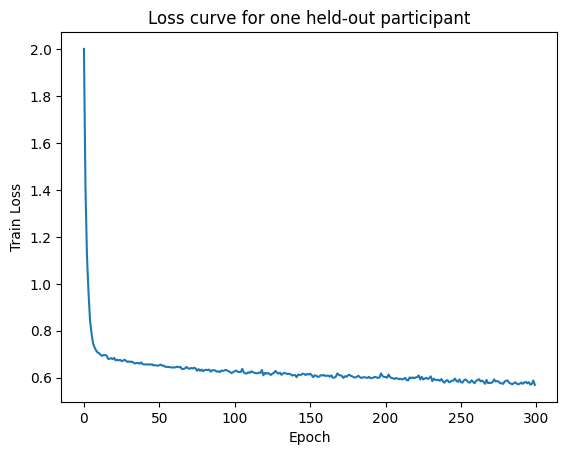

In [ ]:
# # Pick one held-out participant just for this diagnostic, not the full 23
# test_participant_diag = 0
# train_participants_diag = [p for p in range(23) if p != test_participant_diag]

# train_dataset_diag = [dataset_dasps_fc[j] for j in range(276) if j // 12 in train_participants_diag]
# test_dataset_diag = [dataset_dasps_fc[j] for j in range(276) if j // 12 == test_participant_diag]

# gat_diag = BrainSync_8(5, 4, 4)
# optimizer_diag = torch.optim.Adam(gat_diag.parameters(), lr=0.001)

# train_anxious_diag = sum(1 for d in train_dataset_diag if d.y.item() == 1)
# train_nonanxious_diag = sum(1 for d in train_dataset_diag if d.y.item() == 0)

# weights_diag = torch.tensor([
#     (train_anxious_diag + train_nonanxious_diag) / (2 * train_nonanxious_diag),
#     (train_anxious_diag + train_nonanxious_diag) / (2 * train_anxious_diag)
# ])
# criterion_diag = torch.nn.CrossEntropyLoss(weights_diag)

# train_loader_diag = DataLoader(train_dataset_diag, batch_size=16, shuffle=True)

# losses_by_epoch = []

# for epoch in range(300):
#     total_loss = 0
#     n_batches = 0
#     for data in train_loader_diag:
#         optimizer_diag.zero_grad()
#         out = gat_diag(data.x, data.edge_index, data.batch)
#         loss = criterion_diag(out, data.y)
#         loss.backward()
#         optimizer_diag.step()
#         total_loss += loss.item()
#         n_batches += 1

#     avg_loss = total_loss / n_batches
#     losses_by_epoch.append(avg_loss)

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}: Loss {avg_loss:.4f}")

# plt.plot(losses_by_epoch)
# plt.xlabel("Epoch")
# plt.ylabel("Train Loss")
# plt.title("Loss curve for one held-out participant")
# plt.show()

### LOSO execution

In [ ]:
participants = list(range(23))

random.seed(42)
random.shuffle(participants)

preds_total_arr = []
ground_truth_total_arr = []
accuracy_arr = []

for i in range(len(dataset_dasps_fc)//12):
    train_participant = [participants[j] for j in range(len(participants)) if j != i]
    test_participant = [participants[i]]

    train_dataset = [dataset_dasps_fc[j] for j in range(276) if j // 12 in train_participant]
    test_dataset = [dataset_dasps_fc[j] for j in range(276) if j // 12 in test_participant]
    
    gat_dasps = BrainSync_8(5, 4, 4)
    optimizer_dasps = torch.optim.Adam(gat_dasps.parameters(), lr = 0.001)

    train_anxious = sum(1 for data in train_dataset if data.y.item() == 1)
    train_nonanxious = sum(1 for data in train_dataset if data.y.item() == 0)

    anx_w = (train_anxious + train_nonanxious) / (2 * train_anxious)
    nonanx_w = (train_anxious + train_nonanxious) / (2 * train_nonanxious)

    weights = torch.tensor([nonanx_w, anx_w])

    criterion_dasps = torch.nn.CrossEntropyLoss(weights)#Performs weighted loss calc to manage class imbal

    preds = []
    ground_truth = []

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    for epoch in range(100):
        losses = 0

        for data in train_loader:
            optimizer_dasps.zero_grad()
            out = gat_dasps(data.x, data.edge_index, data.batch)
            loss = criterion_dasps(out, data.y)
            loss.backward()
            optimizer_dasps.step()
            losses += loss

        # if epoch % 10 == 0: 
            
        #     print(f"Epoch: {epoch} => Loss: {losses/len(train_dataset)}")

    with torch.no_grad():
        for data in test_loader:
            out = gat_dasps(data.x, data.edge_index, data.batch)
            preds.extend(torch.argmax(out, dim=1).tolist())
            preds_total_arr.extend(torch.argmax(out, dim=1).tolist())
            ground_truth.extend(data.y.tolist())
            ground_truth_total_arr.extend(data.y.tolist())

    true_pos = 0
    false_pos = 0
    true_neg = 0
    false_neg = 0

    for j in range(len(preds)):
        if preds[j] == 0:
            if preds[j] == ground_truth[j]:
                true_neg += 1
            else:
                false_neg += 1
        if preds[j] == 1:
            if preds[j] == ground_truth[j]:
                true_pos += 1
            else: false_pos += 1

    total = true_pos + false_pos + true_neg + false_neg

    accuracy = (true_pos + true_neg) / (total)
    accuracy_arr.append(accuracy)

true_pos = 0
false_pos = 0
true_neg = 0
false_neg = 0

for j in range(len(preds_total_arr)):
        if preds_total_arr[j] == 0:
            if preds_total_arr[j] == ground_truth_total_arr[j]:
                true_neg += 1
            else:
                false_neg += 1
        if preds_total_arr[j] == 1:
            if preds_total_arr[j] == ground_truth_total_arr[j]:
                true_pos += 1
            else: false_pos += 1

predicted_positive = true_pos + false_pos
actual_positive = true_pos + false_neg
predicted_negative = true_neg + false_neg
actual_negative = true_neg + false_pos

precision = (true_pos) / (predicted_positive)
recall = (true_pos) / (actual_positive)
f1_score = (2 * precision * recall) / (precision + recall)

acc_mean_loso = np.mean(accuracy_arr)
acc_std_loso = np.std(accuracy_arr, ddof=1)
print(f"LOSO Accuracy: {acc_mean_loso:.3f} ± {acc_std_loso:.3f}")
print(f"LOSO Pooled F1: {f1_score:.3f}")

### 5 fold Execution

In [ ]:
anxious_participants_total = []
nonanxious_participants_total = []

for p in range(23):
    if regim_df['Anxiety'][p * 12] == 1:
        anxious_participants_total.append(p)
    else:
        nonanxious_participants_total.append(p)

folds = 5

random.seed(42)

random.shuffle(anxious_participants_total)
random.shuffle(nonanxious_participants_total)

equal_chunks_anx = len(anxious_participants_total) // folds #Gives the minimum number of anx participants that are in each chunk
equal_chunks_nonanx = len(nonanxious_participants_total) // folds # Gives the minimum number of non anx participants that are in each chunk

extra_chunks_anx = len(anxious_participants_total) % folds # Gives the number of chunks which will get the extra participants on top of the minimum number
extra_chunks_nonanx = len(nonanxious_participants_total) % folds

# The idea is to first distribute the min_part participants in 5 groups and then distribute the remaining ones

folds_arr = []

for i in range(folds):
    folds_arr.append([])

start_anx = 0
start_nonanx = 0

for i in range(folds):
    if i < extra_chunks_anx:
        folds_arr[i].append(anxious_participants_total[start_anx: start_anx + equal_chunks_anx + 1])
        start_anx = start_anx + equal_chunks_anx + 1

    else: 
        folds_arr[i].append(anxious_participants_total[start_anx: start_anx + equal_chunks_anx])
        start_anx = start_anx + equal_chunks_anx

    if i < extra_chunks_nonanx:
        folds_arr[i].append(nonanxious_participants_total[start_nonanx: start_nonanx + equal_chunks_nonanx + 1])
        start_nonanx = start_nonanx + equal_chunks_nonanx + 1
    else: 
        folds_arr[i].append(nonanxious_participants_total[start_nonanx: start_nonanx + equal_chunks_nonanx])
        start_nonanx = start_nonanx + equal_chunks_nonanx


    folds_arr[i] = folds_arr[i][0] + folds_arr[i][1]

In [ ]:
seeds = [1, 2, 3, 4, 5]

fiveFold_acc_across_seeds = []
fiveFold_f1_across_seeds = []

for seed in seeds: 
    torch.manual_seed(seed)
    random.seed(seed)

    f1_arr_5fold = []
    acc_arr_5fold = []

    for i in range(folds):
        train_dataset_indices = sum((folds_arr[k] for k in range(folds) if k != i), [])
        train_dataset = [dataset_dasps_fc[i] for i in range(276) if i // 12 in train_dataset_indices]
        
        test_dataset_indices = folds_arr[i]
        test_dataset = [dataset_dasps_fc[i] for i in range(276) if i // 12 in test_dataset_indices]

        gat_dasps = BrainSync_8(5, 4, 4)
        optimizer_dasps = torch.optim.Adam(gat_dasps.parameters(), lr = 0.001)

        train_anxious = sum(1 for data in train_dataset if data.y.item() == 1)
        train_nonanxious = sum(1 for data in train_dataset if data.y.item() == 0)

        anx_w = (train_anxious + train_nonanxious) / (2 * train_anxious)
        nonAnx_w = (train_anxious + train_nonanxious) / (2 * train_nonanxious)

        weights = torch.tensor([nonAnx_w, anx_w])
        criterion_dasps = torch.nn.CrossEntropyLoss(weights) #Performs weighted loss calc to manage class imbal

        preds = []
        ground_truth = []

        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

        for epoch in range(100):
            losses = 0

            for data in train_loader:
                optimizer_dasps.zero_grad()
                out = gat_dasps(data.x, data.edge_index, data.batch)
                loss = criterion_dasps(out, data.y)
                loss.backward()
                optimizer_dasps.step()
                losses += loss

            # if epoch % 10 == 0: 
                
            #     print(f"Epoch: {epoch} => Loss: {losses/len(train_dataset)}")

        with torch.no_grad():
            for data in test_loader:
                out = gat_dasps(data.x, data.edge_index, data.batch)
                preds.extend(torch.argmax(out, dim=1).tolist())
                ground_truth.extend(data.y.tolist())

        true_pos = 0
        false_pos = 0
        true_neg = 0
        false_neg = 0

        for j in range(len(preds)):
            if preds[j] == 0:
                if preds[j] == ground_truth[j]:
                    true_neg += 1
                else:
                    false_neg += 1
            if preds[j] == 1:
                if preds[j] == ground_truth[j]:
                    true_pos += 1
                else: false_pos += 1

        total = true_pos + false_pos + true_neg + false_neg

        predicted_positive = true_pos + false_pos
        actual_positive = true_pos + false_neg
        predicted_negative = true_neg + false_neg
        actual_negative = true_neg + false_pos

        accuracy = (true_pos + true_neg) / (total)
        precision = (true_pos) / (predicted_positive)
        recall = (true_pos) / (actual_positive)
        f1_score = (2 * precision * recall) / (precision + recall)

        f1_arr_5fold.append(f1_score)
        acc_arr_5fold.append(accuracy)  

    f1_final_5fold = sum(f1_arr_5fold) / len(f1_arr_5fold)
    acc_final_5fold = sum(acc_arr_5fold) / len(acc_arr_5fold)

    f1_std_5fold = np.std(f1_arr_5fold, ddof=1)
    acc_std_5fold = np.std(acc_arr_5fold, ddof=1)

    fiveFold_acc_across_seeds.append(acc_final_5fold)
    fiveFold_f1_across_seeds.append(f1_final_5fold)

    print(f"5-Fold F1: {f1_final_5fold:.3f} ± {f1_std_5fold:.3f}")
    print(f"5-Fold Accuracy: {acc_final_5fold:.3f} ± {acc_std_5fold:.3f}")

print(f"Across {len(seeds)} seeds — Accuracy: {np.mean(fiveFold_acc_across_seeds):.3f} ± {np.std(fiveFold_acc_across_seeds, ddof=1):.3f}")
print(f"Across {len(seeds)} seeds — F1: {np.mean(fiveFold_f1_across_seeds):.3f} ± {np.std(fiveFold_f1_across_seeds, ddof=1):.3f}")

5-Fold F1: 0.656 ± 0.092
5-Fold Accuracy: 0.600 ± 0.082
5-Fold F1: 0.556 ± 0.115
5-Fold Accuracy: 0.503 ± 0.091
5-Fold F1: 0.638 ± 0.073
5-Fold Accuracy: 0.587 ± 0.069
5-Fold F1: 0.599 ± 0.097
5-Fold Accuracy: 0.539 ± 0.075
5-Fold F1: 0.637 ± 0.074
5-Fold Accuracy: 0.560 ± 0.076
Across 5 seeds — Accuracy: 0.558 ± 0.039
Across 5 seeds — F1: 0.617 ± 0.040


## Result history

#### Before normalization 

LOSO Accuracy: 0.453 ± 0.226 || LOSO Pooled F1: 0.524

5-Fold F1: 0.657 ± 0.062 || 5-Fold Accuracy: 0.597 ± 0.092

---

#### After normalization

LOSO Accuracy: 0.504 ± 0.231 || LOSO Pooled F1: 0.584

CPU RUN:-

5-Fold F1: 0.511 ± 0.249 || 5-Fold Accuracy: 0.484 ± 0.162

COLAB RUN - Across 5 seeds

5-Fold F1: 0.517 ± 0.038 || 5-Fold Accuracy: 0.485 ± 0.035

---

#### After Z-normalization

LOSO Accuracy: 0.496 ± 0.240 || LOSO Pooled F1: 0.572

Across 5 seeds (5 fold) 

5-Fold F1: 0.630 ± 0.012 || 5-Fold Accuracy: 0.568 ± 0.010 

---

#### Functional connectivity

LOSO Accuracy: 0.576 ± 0.223 || LOSO Pooled F1: 0.642

Across 5 seeds — 

5-Fold F1: 0.617 ± 0.040 || 5-Fold Accuracy: 0.558 ± 0.039  